<div style="
    padding:24px 26px;
    border-radius:14px;
    background:linear-gradient(135deg,#16324F,#2F6F7E);
    margin-bottom:20px;
    box-shadow:0 6px 18px rgba(22,50,79,0.14);
">

<h1 style="
    margin:0;
    color:white;
    font-size:34px;
">
Cardiac Patient Monitoring System
</h1>

<p style="
    margin:8px 0 0 0;
    color:#EAF3F5;
    font-size:18px;
">
Milestone 2 — Exploratory Data Analysis & Statistics
</p>

<p style="
    margin:6px 0 0 0;
    color:#DDECEF;
    font-size:14px;
">
Understanding patient patterns before model training
</p>

</div>

<div style="
    background:#ffffff;
    border:1px solid #DCE5E8;
    border-radius:12px;
    padding:18px 20px;
    margin:12px 0 18px 0;
">

<h2 style="
    color:#16324F;
    margin-top:0;
">
Introduction
</h2>

<p style="color:#3F4A52;">
Milestone 1 showed that the dataset is complete and does not contain missing or duplicate records.
</p>

<p style="color:#3F4A52;">
Now I want to look deeper into the patient data and understand the patterns that may be related to heart disease.
</p>

<p style="color:#3F4A52; margin-bottom:0;">
In this milestone, I will study the target distribution, numerical features, relationships, correlations, and possible outliers before moving to supervised learning.
</p>

</div>

<div style="
    background:#F6F9FA;
    border:1px solid #DCE5E8;
    border-radius:12px;
    padding:16px 18px;
    margin:12px 0 20px 0;
">

<p style="
    color:#16324F;
    font-weight:bold;
    font-size:18px;
    margin-top:0;
">
Milestone 2 Roadmap
</p>

<div style="
    display:flex;
    flex-wrap:wrap;
    align-items:center;
    gap:8px;
    color:#3F4A52;
">

<span style="background:white;padding:8px 12px;border-radius:8px;">
Load Checked Data
</span>

<span style="color:#2F6F7E;font-weight:bold;">→</span>

<span style="background:white;padding:8px 12px;border-radius:8px;">
Class Balance
</span>

<span style="color:#2F6F7E;font-weight:bold;">→</span>

<span style="background:white;padding:8px 12px;border-radius:8px;">
Distributions
</span>

<span style="color:#2F6F7E;font-weight:bold;">→</span>

<span style="background:white;padding:8px 12px;border-radius:8px;">
Relationships
</span>

<span style="color:#2F6F7E;font-weight:bold;">→</span>

<span style="background:white;padding:8px 12px;border-radius:8px;">
Correlations
</span>

<span style="color:#2F6F7E;font-weight:bold;">→</span>

<span style="
    background:#DDECEF;
    padding:8px 12px;
    border-radius:8px;
    color:#16324F;
    font-weight:bold;
">
EDA Findings
</span>

</div>

</div>

<h2 style="
    color:#2F6F7E;
    font-weight:bold;
">
1. Load the Checked Dataset
</h2>

<div style="
    background:#ffffff;
    border:1px solid #DCE5E8;
    border-radius:10px;
    padding:14px 16px;
    margin:10px 0 14px 0;
">

<p style="
    color:#3F4A52;
    margin:0;
">
I will continue from the checked dataset saved at the end of Milestone 1.
</p>

</div>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the checked dataset from Milestone 1
df = pd.read_csv("../data/heart_cleveland_checked.csv")

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,0,145,233,1,2,150,0,2.3,2,0,2,0
1,67,1,3,160,286,0,2,108,1,1.5,1,3,1,1
2,67,1,3,120,229,0,2,129,1,2.6,1,2,3,1
3,37,1,2,130,250,0,0,187,0,3.5,2,0,1,0
4,41,0,1,130,204,0,2,172,0,1.4,0,0,1,0


<h2 style="
    color:#2F6F7E;
    font-weight:bold;
">
2. Target Distribution and Class Balance
</h2>

<div style="
    background:#ffffff;
    border:1px solid #DCE5E8;
    border-radius:10px;
    padding:14px 16px;
    margin:10px 0 14px 0;
">

<p style="
    color:#3F4A52;
    margin:0;
">
Before studying the patient features, I will first check how the target classes are distributed.
</p>

</div>

<div style="
    background:#F6F9FA;
    border-left:4px solid #2F6F7E;
    border-radius:8px;
    padding:13px 15px;
    margin:12px 0 16px 0;
">

<p style="
    color:#2F6F7E;
    font-weight:bold;
    margin-top:0;
">
Question
</p>

<p style="
    color:#3F4A52;
    margin-bottom:0;
">
Is the dataset balanced between patients with and without heart disease?
</p>

</div>

In [3]:
# Count patients in each target class
target_counts = df["target"].value_counts()

# Calculate the proportion of each class
target_proportions = df["target"].value_counts(normalize=True)
print("Target Counts:")
print(target_counts)
print("\nTarget Proportions:")
print(target_proportions)

Target Counts:
target
0    164
1    139
Name: count, dtype: int64

Target Proportions:
target
0    0.541254
1    0.458746
Name: proportion, dtype: float64


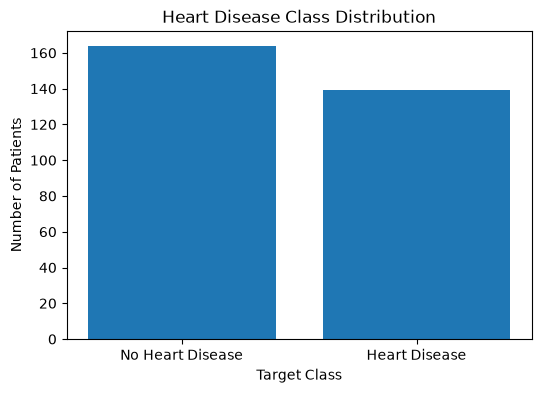

In [4]:
# Plot the target distribution
plt.figure(figsize=(6, 4))

plt.bar(
    ["No Heart Disease", "Heart Disease"],
    target_counts.values
)

plt.xlabel("Target Class")
plt.ylabel("Number of Patients")
plt.title("Heart Disease Class Distribution")

plt.show()

<p style="
    color:#3F4A52;
    background:#EAF3F5;
    padding:10px 12px;
    border-radius:8px;
">
<b style="color:#2F6F7E;">Observation:</b><br>
The dataset contains 164 patients without heart disease and 139 patients with heart disease. The difference between the two classes is only 25 patients, so the target distribution is fairly balanced.
</p>

<h2 style="color:#2F6F7E;">3. Descriptive Statistics</h2>

<p style="color:#3F4A52;">
Now I will summarize the main numerical measurements to understand the typical patient values and how much they vary.
</p>

In [5]:
# Select the main continuous numerical features
numerical_features = [
    "age",
    "trestbps",
    "chol",
    "thalach",
    "oldpeak"
]

# Show descriptive statistics
df[numerical_features].describe().round(2)

,age,trestbps,chol,thalach,oldpeak
count,303.00,303.00,303.00,303.00,303.00
mean,54.44,131.69,246.69,149.61,1.04
std,9.04,17.60,51.78,22.88,1.16
min,29.00,94.00,126.00,71.00,0.00
25%,48.00,120.00,211.00,133.50,0.00
50%,56.00,130.00,241.00,153.00,0.80
75%,61.00,140.00,275.00,166.00,1.60
max,77.00,200.00,564.00,202.00,6.20


<p style="
    color:#3F4A52;
    background:#EAF3F5;
    padding:10px 12px;
    border-radius:8px;
">
<b style="color:#2F6F7E;">Observation:</b><br>
The average patient age is about <b>54 years</b>, with most patients falling between <b>48 and 61 years</b>.<br><br>
Resting blood pressure has a mean of about <b>132 mm Hg</b>, while cholesterol has a mean of about <b>247 mg/dl</b> and shows a wider spread, reaching a maximum of <b>564 mg/dl</b>.<br><br>
The average maximum heart rate is about <b>150 bpm</b>, and <code>oldpeak</code> has a median of <b>0.80</b> but reaches as high as <b>6.20</b>, which suggests that some values may need closer inspection later.
</p>

In [6]:
# Calculate mean, median, and standard deviation
statistics_summary = pd.DataFrame({
    "Mean": df[numerical_features].mean(),
    "Median": df[numerical_features].median(),
    "Std": df[numerical_features].std()
}).round(2)

statistics_summary

,Mean,Median,Std
age,54.44,56.0,9.04
trestbps,131.69,130.0,17.60
chol,246.69,241.0,51.78
thalach,149.61,153.0,22.88
oldpeak,1.04,0.8,1.16


<p style="
    color:#3F4A52;
    background:#EAF3F5;
    padding:10px 12px;
    border-radius:8px;
">
<b style="color:#2F6F7E;">Observation:</b><br>
The mean and median are fairly close for <code>age</code>, <code>trestbps</code>, and <code>thalach</code>, which suggests that these features are not strongly skewed.<br><br>
For <code>chol</code> and <code>oldpeak</code>, the mean is higher than the median. This may indicate some higher values pulling the average upward.<br><br>
<code>chol</code> also has the largest standard deviation at about <b>51.78</b>, showing that cholesterol values vary more than the other features in this summary.
</p>

<h2 style="color:#2F6F7E;">4. Numerical Feature Distributions</h2>

<p style="color:#3F4A52;">
Now I will visualize the main numerical features to see how their values are distributed across the patients.
</p>

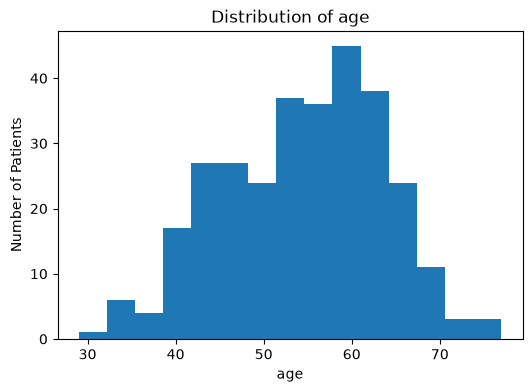

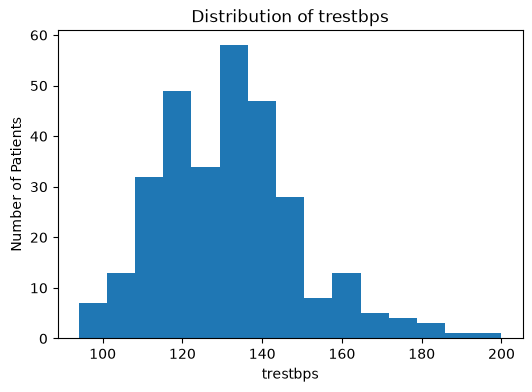

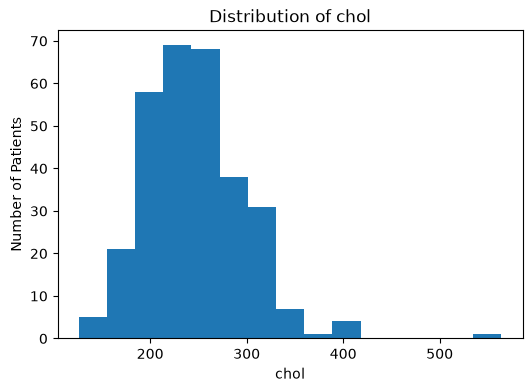

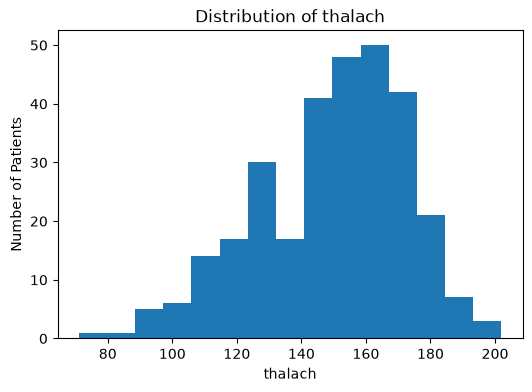

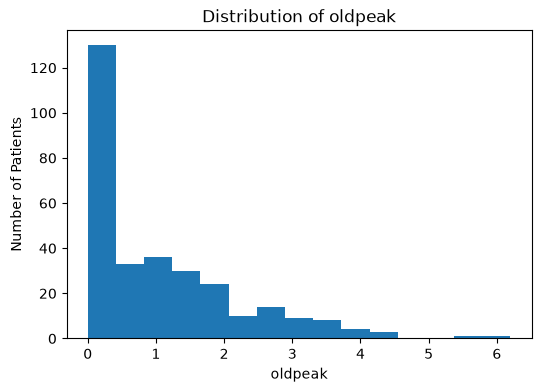

In [8]:
# Plot distributions one by one
for feature in numerical_features:
    plt.figure(figsize=(6, 4))

    plt.hist(
        df[feature],
        bins=15
    )

    plt.xlabel(feature)
    plt.ylabel("Number of Patients")
    plt.title(f"Distribution of {feature}")

    plt.show()

<p style="
    color:#3F4A52;
    background:#EAF3F5;
    padding:10px 12px;
    border-radius:8px;
">
<b style="color:#2F6F7E;">Observation:</b><br>
The <code>age</code> distribution is concentrated mostly between the late 40s and early 60s.<br><br>

<code>trestbps</code> is centered around the 120–140 mm Hg range, with a smaller number of patients having much higher values.<br><br>

<code>chol</code> is more right-skewed than the other features, with most values around 200–300 mg/dl and a few very high values above 400 mg/dl.<br><br>

<code>thalach</code> is concentrated mainly between about 140 and 170 bpm, with fewer patients at the very low or very high ends.
</p>